In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.axes._axes import _log as matplotlib_axes_logger
from mpl_toolkits import mplot3d
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from matplotlib.colors import ListedColormap

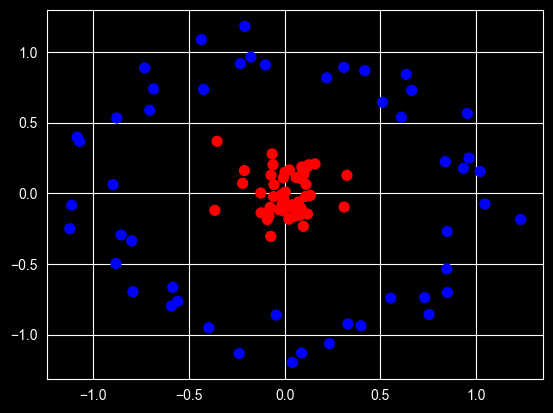

In [3]:
from sklearn.datasets import make_circles
X, y = make_circles(100, factor=.1, noise=.1)

plt.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='bwr')

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.20)

In [5]:
classifier = SVC(kernel="linear")
classifier.fit(X_train, y_train.ravel())
y_pred = classifier.predict(X_test)
from sklearn.metrics import accuracy_score
accuracy_score(y_test, y_pred)

0.65

In [6]:
zero_one_colourmap = ListedColormap(('blue', 'red'))
def plot_decision_boundary(X, y, clf):
    X_set, y_set = X, y
    X1, X2 = np.meshgrid(np.arange(start = X_set[:, 0].min() - 1,
                                 stop = X_set[:, 0].max() + 1,
                                 step = 0.01),
                       np.arange(start = X_set[:, 1].min() - 1,
                                 stop = X_set[:, 1].max() + 1,
                                 step = 0.01))

    plt.contourf(X1, X2, clf.predict(np.array([X1.ravel(),
                                             X2.ravel()]).T).reshape(X1.shape),
               alpha = 0.75,
               cmap = zero_one_colourmap)
    plt.xlim(X1.min(), X1.max())
    plt.ylim(X2.min(), X2.max())
    for i, j in enumerate(np.unique(y_set)):
        plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1],
                c = (zero_one_colourmap)(i), label = j)
    plt.title('SVM Decision Boundary')
    plt.xlabel('X1')
    plt.ylabel('X2')
    plt.legend()
    return plt.show()

C:\Users\rohit\AppData\Local\Temp\ipykernel_916\2718072598.py:18: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1],


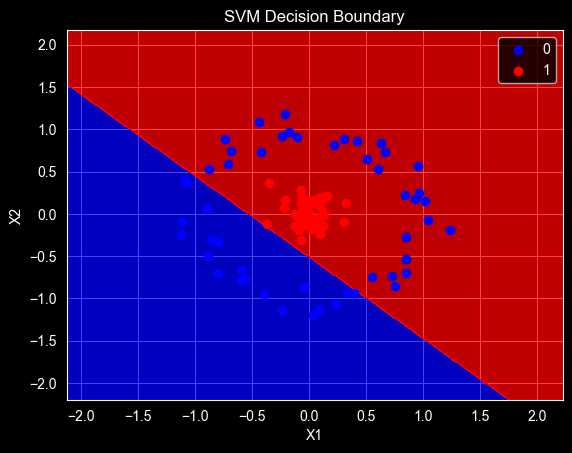

In [7]:
plot_decision_boundary(X, y, classifier)

In [8]:
def plot_3d_plot(X, y):
    r = np.exp(-(X ** 2).sum(1))
    ax = plt.subplot(projection='3d')
    ax.scatter3D(X[:, 0], X[:, 1], r, c=y, s=100, cmap='bwr')
    ax.set_xlabel('X1')
    ax.set_ylabel('X2')
    ax.set_zlabel('y')
    return ax

<Axes3D: xlabel='X1', ylabel='X2', zlabel='y'>

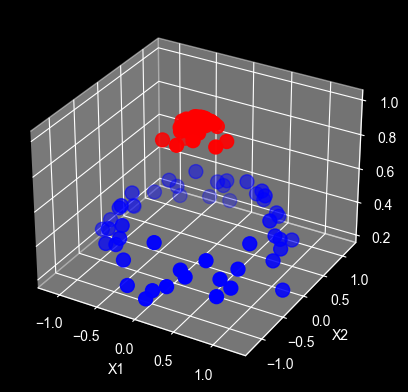

In [9]:
plot_3d_plot(X,y)

In [10]:
rbf_classifier = SVC(kernel="rbf")
rbf_classifier.fit(X_train, y_train)
y_pred = rbf_classifier.predict(X_test)

In [11]:
accuracy_score(y_test, y_pred)

1.0

C:\Users\rohit\AppData\Local\Temp\ipykernel_916\2718072598.py:18: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1],


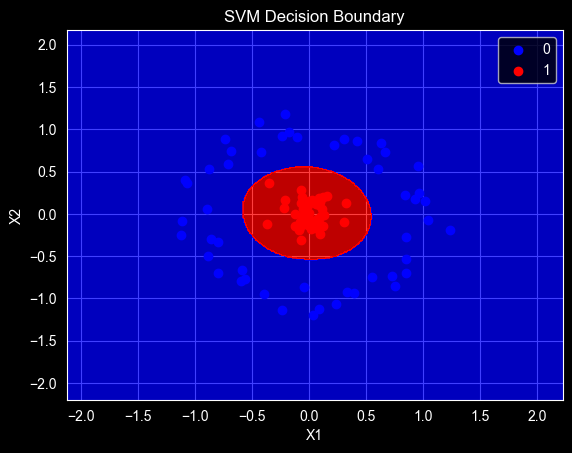

In [12]:
plot_decision_boundary(X, y, rbf_classifier)

In [13]:
poly_classifier = SVC(kernel="poly",degree=2)
poly_classifier.fit(X_train, y_train)
y_pred = poly_classifier.predict(X_test)

In [14]:
accuracy_score(y_test, y_pred)

1.0

C:\Users\rohit\AppData\Local\Temp\ipykernel_916\2718072598.py:18: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1],


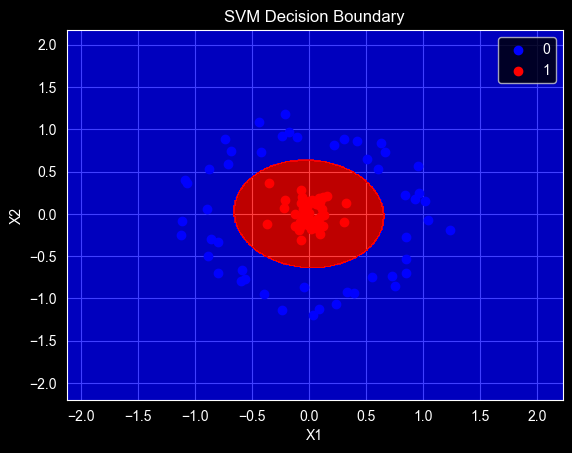

In [15]:
plot_decision_boundary(X, y, poly_classifier)

In [16]:
X

array([[ 7.31715772e-01, -7.38817475e-01],
       [ 6.09863913e-01,  5.36565589e-01],
       [-5.59500377e-01, -7.65085512e-01],
       [-5.59938802e-02,  5.99230864e-02],
       [-4.35425255e-01,  1.08637755e+00],
       [-1.11332644e+00, -8.45944153e-02],
       [ 8.39886640e-01,  2.23291893e-01],
       [-9.08289692e-02, -1.86035278e-01],
       [ 8.49432403e-01, -2.70338848e-01],
       [-1.24889506e-01,  1.13217983e-03],
       [ 4.60001286e-02, -9.88058203e-02],
       [ 1.09570059e-01, -2.18106362e-02],
       [ 6.35611000e-01,  8.40882074e-01],
       [-8.77168142e-01,  5.31977047e-01],
       [-5.84744419e-01, -6.65533672e-01],
       [-5.79535597e-02, -2.37094510e-02],
       [ 1.58610988e-01,  2.07953921e-01],
       [ 8.47374181e-01, -5.35986582e-01],
       [ 1.11495666e-01,  6.22678545e-02],
       [-7.63419956e-02, -9.99002713e-02],
       [ 8.68133285e-02,  1.01358043e-01],
       [ 3.10506239e-01, -9.73640186e-02],
       [-7.28854585e-02, -3.05415488e-01],
       [-1.

In [17]:
np.exp(-(X**2)).sum(1)

array([1.1647788 , 1.43923435, 1.28812783, 1.99328526, 1.13450631,
       1.2823995 , 1.44526955, 1.95776696, 1.41552906, 1.98452234,
       1.98817113, 1.98759059, 1.16072381, 1.21679997, 1.35254965,
       1.99608504, 1.93283326, 1.23800616, 1.98377589, 1.98425842,
       1.98227091, 1.89865292, 1.90564145, 1.96588029, 1.93727217,
       1.99189582, 1.46644148, 1.98180579, 1.47411484, 1.36434396,
       1.26905011, 1.04106435, 1.98564406, 1.97558811, 1.23416944,
       1.27101813, 1.96528288, 1.75629708, 1.99102799, 1.98830788,
       1.88371967, 1.43125785, 1.978457  , 1.31063866, 1.23686606,
       1.16249477, 1.99869505, 1.99055389, 1.25865808, 1.93122904,
       1.41797681, 1.38700186, 1.95650109, 1.14893872, 1.94443396,
       1.99991757, 1.24046471, 1.20623045, 1.96992793, 1.3223387 ,
       1.32865649, 1.92120114, 1.23296725, 1.18469998, 1.26817033,
       1.31211546, 1.41999114, 1.97140711, 1.86048026, 1.97412135,
       1.98421642, 1.22185802, 1.98816241, 1.31649327, 1.22161

In [18]:
X_new=np.exp(-(X**2))

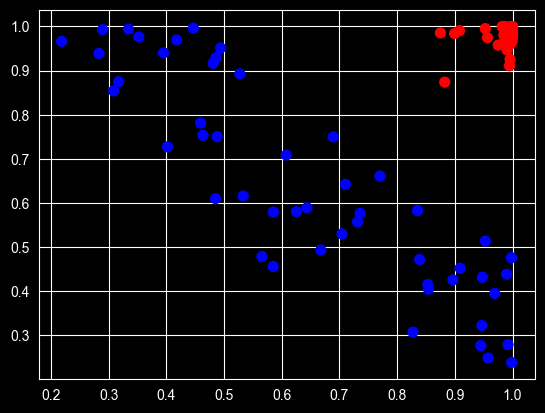

In [19]:
plt.scatter(X_new[:, 0], X_new[:, 1], c=y, s=50, cmap='bwr')